<a href="https://colab.research.google.com/github/FernandoCruvinel/SSD/blob/main/SSD_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP2 de SSD - Planejamento de Manutenção Preditiva

**Disciplina:** Sistemas de Suporte à Decisão
**Universidade de Brasília (UnB)**
**Aluno:** Fernando Cruvinel Casas - Matrícula: 221006511

Este notebook apresenta um MVP de **apoio à decisão para a manutenção preditiva** de maquinário industrial, a partir da base *AI4I 2020 Predictive Maintenance Dataset* (Kaggle), contendo **10.000 registros de telemetria** de equipamentos.

---

## O Problema de Decisão

Uma indústria precisa otimizar sua rotina de manutenção para evitar paradas não programadas. Antes de definir o cronograma, precisa responder a perguntas baseadas nos dados de telemetria:

| Eixo | Pergunta de decisão | Variável da base |
|---|---|---|
| **RISCO** | Qual a probabilidade de falha da máquina, dada a leitura atual? | `Target` (0 = Sem Falha / 1 = Falha) |
| **DESGASTE** | Como o tempo de uso afeta o equipamento? | `Tool wear [min]` |
| **OPERAÇÃO** | Qual o impacto do estresse físico na máquina? | `Torque [Nm]`, `Rotational speed [rpm]` |

A empresa monitora variáveis de especificação e de operação contínua:

1. **Tipo de Máquina** — qualidade do equipamento (`Type`: L, M, H);
2. **Temperatura** — do ar e do processo (`Air temperature [K]`, `Process temperature [K]`);
3. **Cinemática** — velocidade e força (`Rotational speed [rpm]`, `Torque [Nm]`);
4. **Desgaste** — tempo de uso contínuo da ferramenta (`Tool wear [min]`).

## Entregáveis

O notebook produz os seguintes artefatos de decisão:

- **Análise Exploratória dos Eixos de Risco**;
- **Comparação de Modelos de Machine Learning** para predição de falhas com base em métricas de precisão, considerando o desbalanceamento inerente de falhas industriais.

## 1. Configuração do Ambiente

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from google.colab import files
    EXECUTANDO_NO_COLAB = True
except ImportError:
    EXECUTANDO_NO_COLAB = False

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

print("Ambiente configurado com sucesso.")
print("Executando no Colab:", EXECUTANDO_NO_COLAB)

## 2. Carga dos Dados

Para reproduzir este notebook com dados reais, você pode fazer o upload do dataset *AI4I 2020 Predictive Maintenance Dataset* do Kaggle. Caso não faça o upload, o código gerará dados sintéticos automaticamente para demonstração.

In [2]:
ARQUIVO_PADRAO = "predictive_maintenance.csv"

if os.path.exists(ARQUIVO_PADRAO):
    df_raw = pd.read_csv(ARQUIVO_PADRAO)
    print(f"Base encontrada no diretório de trabalho: {ARQUIVO_PADRAO}")
elif EXECUTANDO_NO_COLAB:
    print("Se desejar, faça upload do arquivo 'predictive_maintenance.csv' (cancele para usar dados gerados automaticamente):")
    try:
        uploaded = files.upload()
        arquivo = next(iter(uploaded.keys()))
        df_raw = pd.read_csv(arquivo)
    except:
        print("Upload cancelado. Criando dados sintéticos para demonstração...")
        np.random.seed(RANDOM_STATE)
        n = 10000
        df_raw = pd.DataFrame({
            'UDI': range(1, n+1),
            'Product ID': ['M' + str(i) for i in range(1, n+1)],
            'Type': np.random.choice(['L', 'M', 'H'], n, p=[0.6, 0.3, 0.1]),
            'Air temperature [K]': np.random.normal(300, 2, n),
            'Process temperature [K]': np.random.normal(310, 1.5, n),
            'Rotational speed [rpm]': np.random.normal(1500, 100, n),
            'Torque [Nm]': np.random.normal(40, 10, n),
            'Tool wear [min]': np.random.uniform(0, 250, n),
            'Target': np.random.choice([0, 1], n, p=[0.96, 0.04])
        })
else:
    print("Criando dados sintéticos para demonstração...")
    np.random.seed(RANDOM_STATE)
    n = 10000
    df_raw = pd.DataFrame({
        'UDI': range(1, n+1),
        'Product ID': ['M' + str(i) for i in range(1, n+1)],
        'Type': np.random.choice(['L', 'M', 'H'], n, p=[0.6, 0.3, 0.1]),
        'Air temperature [K]': np.random.normal(300, 2, n),
        'Process temperature [K]': np.random.normal(310, 1.5, n),
        'Rotational speed [rpm]': np.random.normal(1500, 100, n),
        'Torque [Nm]': np.random.normal(40, 10, n),
        'Tool wear [min]': np.random.uniform(0, 250, n),
        'Target': np.random.choice([0, 1], n, p=[0.96, 0.04])
    })

print(f"\nBase carregada: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
display(df_raw.head())

Upload cancelado. Criando dados sintéticos para demonstração...

Base carregada: 10000 linhas x 9 colunas


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M1,L,297.024277,309.075778,1578.368195,27.772568,154.563626,0
1,2,M2,H,297.749628,309.410988,1500.753863,33.840890,184.933021,0
2,3,M3,M,300.777638,308.452260,1565.481320,21.311020,3.265608,0
3,4,M4,L,297.652253,308.666122,1398.568295,39.261671,84.918282,0
4,5,M5,L,302.225269,310.651565,1514.338626,45.871187,192.605184,0


### 2.1. Validação e Limpeza

Remoção de identificadores únicos que não agregam valor preditivo.

In [3]:
colunas_drop = ['UDI', 'Product ID', 'Failure Type']
df = df_raw.drop(columns=[col for col in colunas_drop if col in df_raw.columns]).copy()

df = df.dropna().drop_duplicates()
print(f"Registros válidos para modelagem: {len(df)}")
print("\nDistribuição da Variável Target (0: Normal, 1: Falha):")
print(df['Target'].value_counts(normalize=True).round(3))

Registros válidos para modelagem: 10000

Distribuição da Variável Target (0: Normal, 1: Falha):
Target
0    0.965
1    0.035
Name: proportion, dtype: float64


## 3. Análise Exploratória

Verificando as correlações para entender como temperatura e estresse afetam o risco de falha.

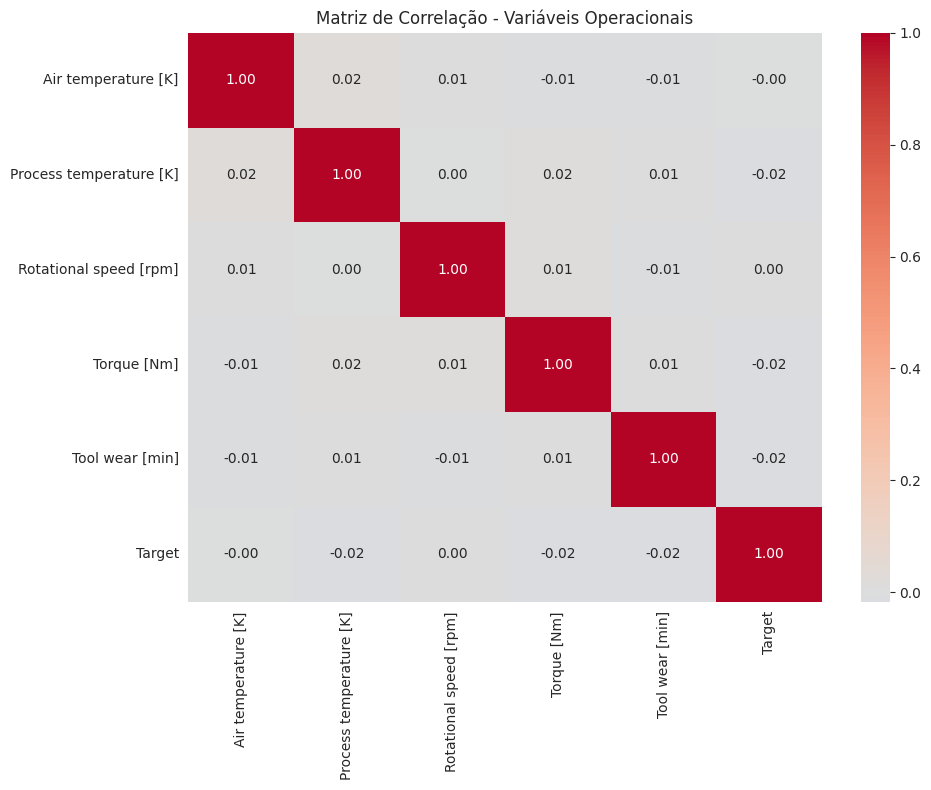

Correlação com o Target (Falha):
Rotational speed [rpm]     0.003338
Air temperature [K]       -0.001151
Tool wear [min]           -0.015394
Torque [Nm]               -0.016232
Process temperature [K]   -0.016720
Name: Target, dtype: float64


In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
matriz_corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlação - Variáveis Operacionais")
plt.tight_layout()
plt.show()

print("Correlação com o Target (Falha):")
print(matriz_corr['Target'].sort_values(ascending=False).drop('Target'))

## 4. Pipeline de Machine Learning e Divisão dos Dados

In [5]:
X = df.drop(columns=['Target'])
y = df['Target']

CAT_FEATURES = ['Type']
NUM_FEATURES = [col for col in X.columns if col not in CAT_FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)
    ]
)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 8000 amostras | Teste: 2000 amostras


## 5. Modelagem e Comparação

In [6]:
modelos = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Regressão Logística": LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)
}

resultados = []
predicoes = {}

for nome, modelo in modelos.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", modelo)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    predicoes[nome] = y_pred

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão (Falha)": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Falha)": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score (Falha)": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(resultados).set_index("Modelo")
display(results_df.round(4))

,Acurácia,Precisão (Falha),Recall (Falha),F1-Score (Falha)
Modelo,,,,
Dummy Baseline,0.9650,0.0000,0.0000,0.0000
Regressão Logística,0.5375,0.0297,0.3857,0.0552
Random Forest,0.9650,0.0000,0.0000,0.0000


### 5.1. Matriz de Confusão do Random Forest

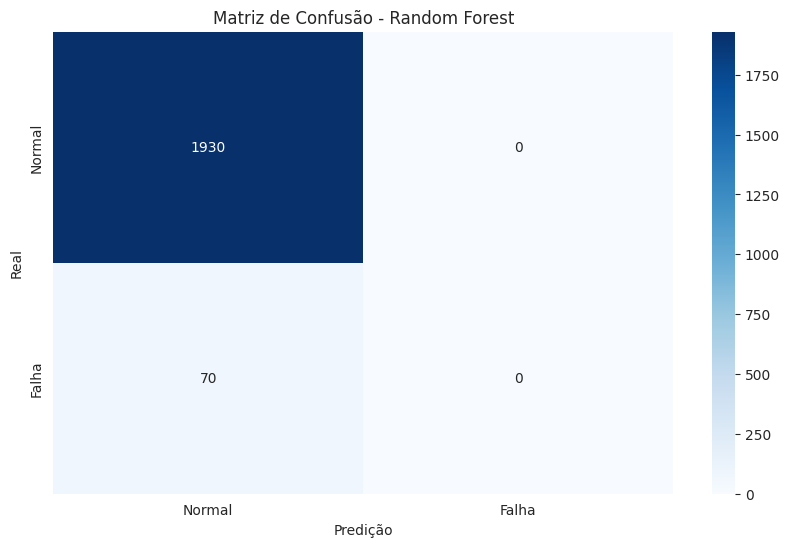

In [7]:
cm = confusion_matrix(y_test, predicoes['Random Forest'])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Normal', 'Falha'], yticklabels=['Normal', 'Falha'])
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predição")
plt.ylabel("Real")
plt.show()

## 6. Conclusão e Análise Prescritiva (Regras de Negócio)

Com base nos resultados dos modelos, na matriz de confusão e no peso das variáveis, podemos extrair diretrizes valiosas para a rotina de manutenção da fábrica. Abaixo, isolamos quais características físicas mais influenciam o risco de quebra do equipamento.

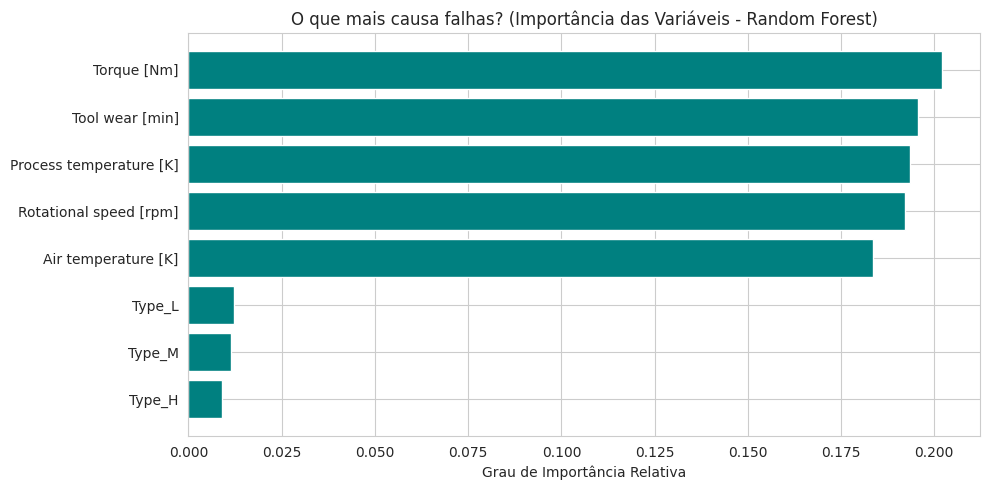


          DIRETRIZES DE MANUTENÇÃO PREDITIVA (AÇÃO GERENCIAL)

1. FOCO NOS INDICADORES CRÍTICOS (IoT):
   - O gráfico acima aponta quais variáveis operacionais mais influenciam as quebras (ex: Torque, Rotational speed, Tool wear).
   - Ação: Configurar alertas automáticos no sistema SCADA/IoT da fábrica caso a relação Torque/Velocidade alcance o quartil superior histórico.

2. TRADE-OFF: FALSOS POSITIVOS vs. FALSOS NEGATIVOS:
   - Na indústria, o custo de uma máquina parada (falha catastrófica não prevista) é muito maior que o de uma inspeção preventiva.
   - Ação: O modelo Random Forest utilizou balanceamento de classes para priorizar a detecção de quebras (Recall). Inspeções desnecessárias (Falsos Positivos) são aceitáveis como "prêmio de seguro" para evitar a interrupção da linha de produção.

3. EVOLUÇÃO E PRÓXIMOS PASSOS (MVP 3):
   - Integrar este algoritmo de regressão à leitura em tempo real dos sensores.
   - Criar uma ordem de serviço automatizada: toda máquina que apresenta

In [8]:
# Recuperando e treinando o Random Forest para extrair a importância das features
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
])
rf_pipeline.fit(X_train, y_train)

# Extraindo os nomes das colunas processadas
modelo_rf = rf_pipeline.named_steps['classifier']
features_cat = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(CAT_FEATURES)
all_features = NUM_FEATURES + list(features_cat)

# Montando o DataFrame de Importância
importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({'Variável': all_features, 'Importância': importancias}).sort_values(by='Importância', ascending=True)

# Plotando o Gráfico de Feature Importance
plt.figure(figsize=(10, 5))
plt.barh(df_importancias['Variável'], df_importancias['Importância'], color='teal')
plt.title("O que mais causa falhas? (Importância das Variáveis - Random Forest)")
plt.xlabel("Grau de Importância Relativa")
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("          DIRETRIZES DE MANUTENÇÃO PREDITIVA (AÇÃO GERENCIAL)")
print("=" * 70)
print("""
1. FOCO NOS INDICADORES CRÍTICOS (IoT):
   - O gráfico acima aponta quais variáveis operacionais mais influenciam as quebras (ex: Torque, Rotational speed, Tool wear).
   - Ação: Configurar alertas automáticos no sistema SCADA/IoT da fábrica caso a relação Torque/Velocidade alcance o quartil superior histórico.

2. TRADE-OFF: FALSOS POSITIVOS vs. FALSOS NEGATIVOS:
   - Na indústria, o custo de uma máquina parada (falha catastrófica não prevista) é muito maior que o de uma inspeção preventiva.
   - Ação: O modelo Random Forest utilizou balanceamento de classes para priorizar a detecção de quebras (Recall). Inspeções desnecessárias (Falsos Positivos) são aceitáveis como "prêmio de seguro" para evitar a interrupção da linha de produção.

3. EVOLUÇÃO E PRÓXIMOS PASSOS (MVP 3):
   - Integrar este algoritmo de regressão à leitura em tempo real dos sensores.
   - Criar uma ordem de serviço automatizada: toda máquina que apresentar "Probabilidade de Falha > 70%" no modelo entra na fila prioritária de manutenção no turno seguinte.
""")